In [1]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from chipanalysis.chip_alignment import align_chip_to_image,get_roi_from_result, ChipGeometry

from PIL import Image
import pandas as pd
import numpy as np
%load_ext autoreload
%autoreload 2

%matplotlib widget

In [2]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
# root_path = "/Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac"

fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB27-01.czi"
czi_name = "CB8-05_S1.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [3]:
channel = 2
time = 0
img, img_disp = get_frame(czi,time,channel)

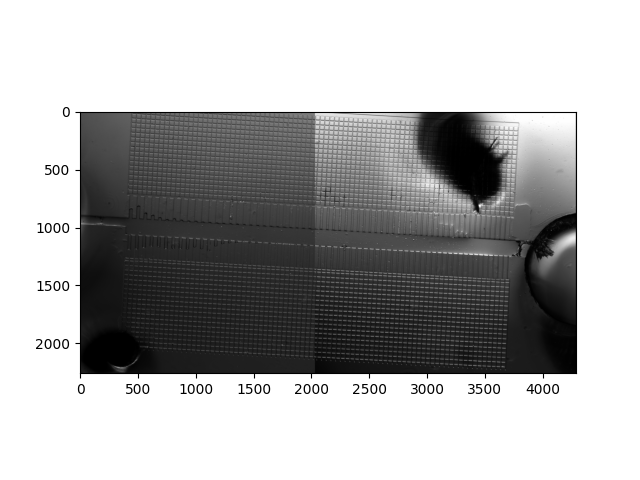

In [4]:
fig,ax = plt.subplots()
ax.imshow(img_disp,cmap="gray")

In [4]:
result = align_chip_to_image(img, pixel_size_um=pixel_size["X"], debug=False, geom=ChipGeometry())

In [5]:
def select_roi(img):
    roi, _ = get_roi_from_result(
    result,
    result['rotate_fn'](img) ,
    pad_left_um=2300.0,   # expand chip box leftward (µm)
    pad_right_um=-7300.0,  # expand chip box rightward (µm)
    pad_top_um=800.0,    # pad above & below main channel centre (symmetric)
    pad_bottom_um=800.0,    # pad above & below main channel centre (symmetric)

)
    return roi

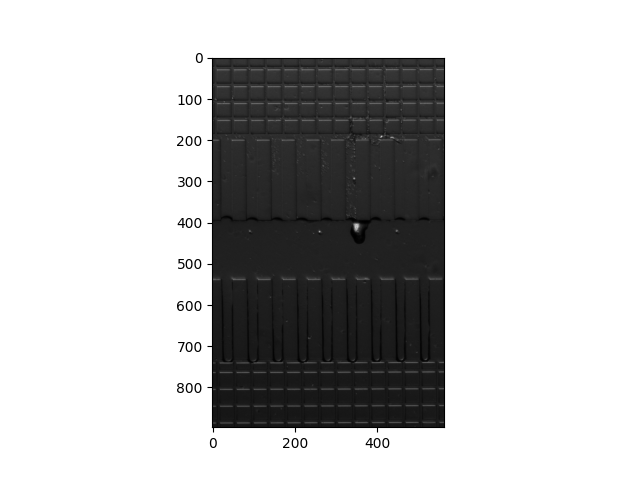

In [6]:

stretch_min = 10
stretch_max = 99.5
channel = 2
time = 13
img, img_disp = get_frame(czi,time,channel,gamma=0.45,stretch_min=stretch_min,stretch_max=stretch_max)
fig,ax = plt.subplots()
ax.imshow(select_roi(img),cmap="gray")

/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_35672/3950254480.py:126: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  filtered_binary = binary_dilation(filtered_binary, footprint=kernel)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_35672/3950254480.py:127: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  filtered_binary = binary_erosion(filtered_binary, footprint=kernel)
/Users/bisot/Documents/PostDoc2/chipanalysis/.venv/lib/python3.12/site-packages/skimage/color/colorlabel.py:149: UserWarning: Negative intensities in `image` are not supported
  rgb = _label2rgb_overlay(
Clipping input data to the valid range for 

Pixels added by bridging: 5  (max gap = 100 µm → 56 px)
Morphological closing applied (radius=5 px)
Found 3 aggregate(s) ≥ 20 µm (≥ 99 px²,  px size = 1.783 µm/px)


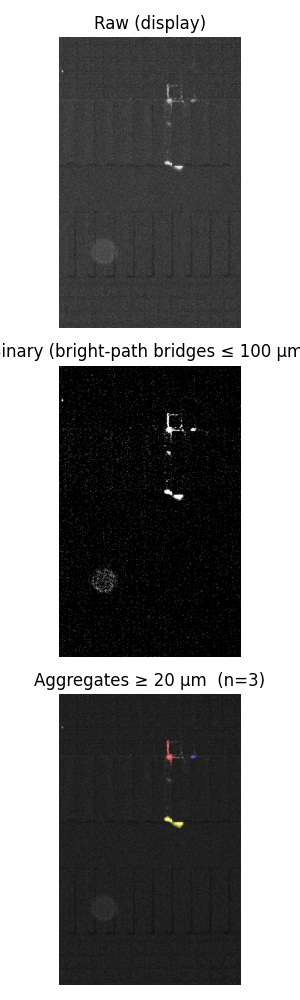

In [6]:

from skimage.filters import threshold_otsu
from skimage.filters import threshold_triangle
from skimage.measure import label, regionprops
from skimage.color import label2rgb
from skimage.graph import route_through_array
from skimage.morphology import binary_dilation, binary_erosion, disk
from scipy.ndimage import label as ndlabel
import matplotlib.pyplot as plt
import numpy as np

# ── Parameters ──────────────────────────────────────────────────────────────
MIN_SIZE_UM   = 20   # minimum aggregate diameter to keep (µm)
MAX_HOLE_UM   = 100  # max gap (µm) between aggregate centroids to attempt bridging
THRESH_FACTOR = 0.95# multiplier for threshold_triangle result (0–1)
MORPH_RADIUS  = 5   # morphological kernel radius (pixels) for closing
channel       = 1    # fluorescence channel
time          = 8

# ── Load & crop image ───────────────────────────────────────────────────────
img_raw, img_disp = get_frame(czi, time, channel, gamma=1,
                               stretch_min=1, stretch_max=99.5)
img_raw  = select_roi(img_raw.astype(float))
img_disp = select_roi(img_disp)

# ── Size / distance thresholds in pixels ─────────────────────────────────────
px_um              = pixel_size["X"]
min_area_px        = np.pi * (MIN_SIZE_UM / 2 / px_um) ** 2
max_hole_area_px   = np.pi * (MAX_HOLE_UM / 2 / px_um) ** 2  # kept for downstream cells
max_bridge_dist_px = MAX_HOLE_UM / px_um                       # centroid gap for bridging

# ── Helper: merge close aggregates via brightest-path bridging ───────────────
def merge_by_bright_path(binary, img_raw, max_dist_px):
    """
    For each pair of detected aggregates whose centroids are within max_dist_px:
      1. Find the brightest path between their centroids using Dijkstra with
         cost = (max_I − I), so the solver routes through the highest-intensity
         pixels.
      2. bridge_thresh = minimum intensity along that path (the bottleneck).
      3. Add all pixels in the bounding box of the pair that are ≥ bridge_thresh
         to the binary mask, bridging the gap through the bright corridor.
    A single pass is performed over all detected pairs.
    """
    lbl   = label(binary)
    props = [p for p in regionprops(lbl) if p.area >= min_area_px]
    out   = binary.copy()

    for i in range(len(props)):
        for j in range(i + 1, len(props)):
            cy0, cx0 = props[i].centroid
            cy1, cx1 = props[j].centroid
            if np.hypot(cy1 - cy0, cx1 - cx0) > max_dist_px:
                continue

            # Bounding box of both regions + small padding
            pad   = 4
            r_min = max(0,                min(props[i].bbox[0], props[j].bbox[0]) - pad)
            c_min = max(0,                min(props[i].bbox[1], props[j].bbox[1]) - pad)
            r_max = min(img_raw.shape[0], max(props[i].bbox[2], props[j].bbox[2]) + pad)
            c_max = min(img_raw.shape[1], max(props[i].bbox[3], props[j].bbox[3]) + pad)

            crop = img_raw[r_min:r_max, c_min:c_max].astype(float)
            # Invert so Dijkstra routes through the brightest pixels
            cost = (crop.max() - crop) + 1e-6

            src = (np.clip(int(round(cy0)) - r_min, 0, crop.shape[0] - 1),
                   np.clip(int(round(cx0)) - c_min, 0, crop.shape[1] - 1))
            dst = (np.clip(int(round(cy1)) - r_min, 0, crop.shape[0] - 1),
                   np.clip(int(round(cx1)) - c_min, 0, crop.shape[1] - 1))

            try:
                path_rc, _ = route_through_array(cost, src, dst, fully_connected=True)
            except Exception:
                continue

            path_rc = np.array(path_rc)

            # Add only the pixels on the bridge path itself
            path_mask = np.zeros_like(crop, dtype=bool)
            path_mask[path_rc[:, 0], path_rc[:, 1]] = True
            out[r_min:r_max, c_min:c_max] |= path_mask

    return out

# ── Helper: fill enclosed background holes (kept for downstream cells) ────────
def fill_small_holes(binary, max_hole_area_px):
    bg_labeled, _ = ndlabel(~binary)
    border_labels = set()
    for edge in (bg_labeled[0, :], bg_labeled[-1, :],
                 bg_labeled[:, 0], bg_labeled[:, -1]):
        border_labels.update(edge.tolist())
    border_labels.discard(0)
    filled = binary.copy()
    for lbl_id in np.unique(bg_labeled):
        if lbl_id == 0 or lbl_id in border_labels:
            continue
        hole_mask = bg_labeled == lbl_id
        if hole_mask.sum() <= max_hole_area_px:
            filled[hole_mask] = True
    return filled

# ── Threshold → binary mask ──────────────────────────────────────────────────
thresh = THRESH_FACTOR * threshold_triangle(img_raw)
# thresh = 190
binary = img_raw > thresh

# ── Merge close aggregates via brightest-path bridging ───────────────────────
binary_filled = merge_by_bright_path(binary, img_raw, max_bridge_dist_px)
n_px_added = int(binary_filled.sum() - binary.sum())
print(f"Pixels added by bridging: {n_px_added}  "
      f"(max gap = {MAX_HOLE_UM} µm → {max_bridge_dist_px:.0f} px)")

# ── Label connected components & filter by size ───────────────────────────────
labeled  = label(binary_filled)
filtered = np.zeros_like(labeled)
new_label = 1
for prop in regionprops(labeled):
    if prop.area >= min_area_px:
        filtered[labeled == prop.label] = new_label
        new_label += 1

n_aggregates = new_label - 1

# ── Morphological closing (fill internal holes) ──────────────────────────────
filtered_binary = filtered > 0
kernel = disk(MORPH_RADIUS)
filtered_binary = binary_dilation(filtered_binary, footprint=kernel)
filtered_binary = binary_erosion(filtered_binary, footprint=kernel)
print(f"Morphological closing applied (radius={MORPH_RADIUS} px)")
# Re-label the closed binary to get clean, connected components
filtered = label(filtered_binary)
print(f"Found {n_aggregates} aggregate(s) ≥ {MIN_SIZE_UM} µm "
      f"(≥ {min_area_px:.0f} px²,  px size = {px_um:.3f} µm/px)")

# ── Coloured overlay ─────────────────────────────────────────────────────────
overlay = label2rgb(filtered, image=img_disp, bg_label=0,
                    alpha=0.4, image_alpha=1.0, kind='overlay')

fig, axes = plt.subplots(3, 1, figsize=(3, 10), sharex=True, sharey=True)
axes[0].imshow(img_disp, cmap="gray")
axes[0].set_title("Raw (display)")
axes[1].imshow(binary_filled, cmap="gray")
axes[1].set_title(f"Binary (bright-path bridges ≤ {MAX_HOLE_UM} µm)")
axes[2].imshow(overlay)
axes[2].set_title(f"Aggregates ≥ {MIN_SIZE_UM} µm  (n={n_aggregates})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
# plt.show()


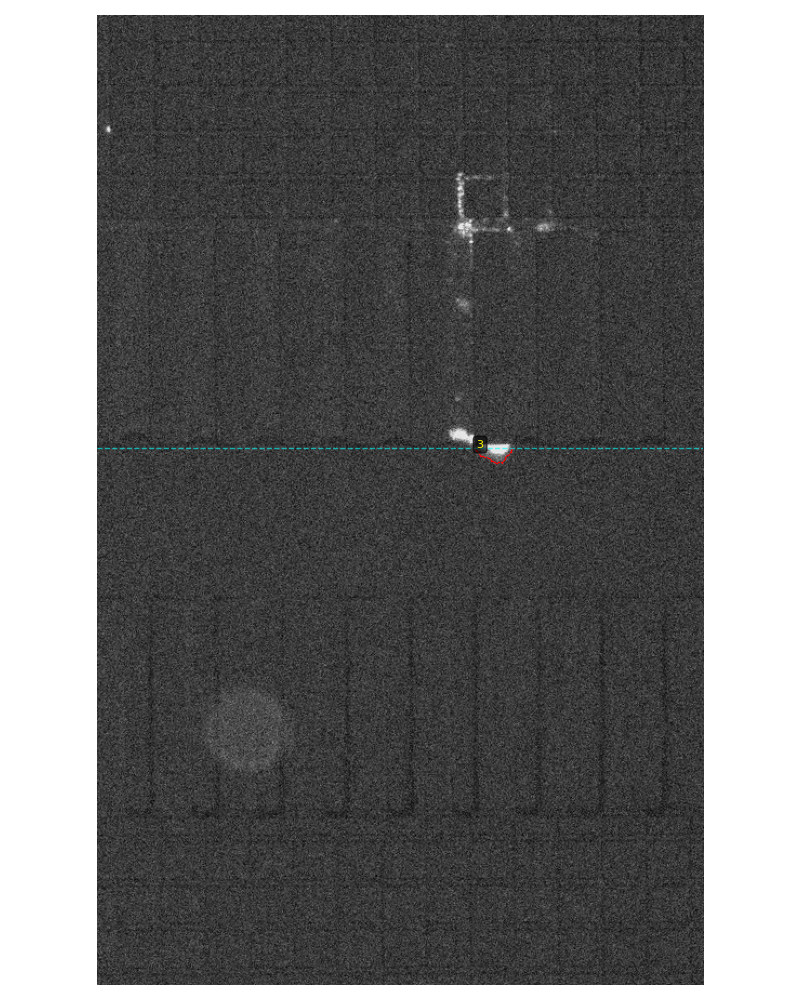

In [7]:

# ── Visualize detected aggregates with boundaries (filtered by y threshold) ────
from skimage.segmentation import find_boundaries

y_threshold_px = 400  # in image coords: y < threshold = above

fig, ax = plt.subplots(figsize=(8, 10))
ax.imshow(img_disp, cmap="gray")
ax.axhline(y=y_threshold_px, color='cyan', linestyle='--', linewidth=1, alpha=0.6)

props_filtered = regionprops(filtered)
for prop in props_filtered:
    # Get all boundary pixels for this aggregate
    boundary = find_boundaries(filtered == prop.label, mode='inner')
    y_coords, x_coords = np.where(boundary)
    # Keep only pixels visually above the threshold (smaller y in image coords)
    mask_above = y_coords >= y_threshold_px
    y_above = y_coords[mask_above]
    x_above = x_coords[mask_above]

    if len(x_above) > 0:
        ax.scatter(x_above, y_above, s=1, c='red', linewidths=0)
        # Label if centroid is also above threshold
        if prop.centroid[0] <= y_threshold_px:
            ax.text(prop.centroid[1], prop.centroid[0], str(prop.label),
                    color='yellow', fontsize=8, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6))

ax.axis("off")
plt.tight_layout()


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_35672/82404549.py:31: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  filtered_binary = binary_dilation(filtered_binary, footprint=kernel)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_35672/82404549.py:32: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  filtered_binary = binary_erosion(filtered_binary, footprint=kernel)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.03622044599339112..1.0694127062389422].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0.

Frame 8: 3 aggregate(s)   |   Frame 9: 4 aggregate(s)
Matched: 3 / 3


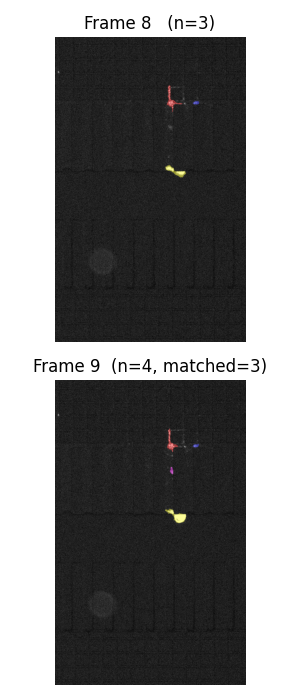

In [8]:

from scipy.optimize import linear_sum_assignment
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
from skimage.color import label2rgb
import numpy as np
import matplotlib.pyplot as plt

# ── Tunable parameters ────────────────────────────────────────────────────────
MAX_DIST_UM  = 200   # max centroid distance (µm) to accept a match
AREA_WEIGHT  = 0.6   # weight of normalised area difference vs. distance

# ── Helper: detect aggregates in one frame ────────────────────────────────────
def detect_frame(t):
    raw, disp = get_frame(czi, t, channel, gamma=1, stretch_min=1, stretch_max=99.5)
    raw  = select_roi(raw.astype(float))
    disp = select_roi(disp)
    thr  = threshold_triangle(raw)
    # thr  = 190
    binary = raw > THRESH_FACTOR * thr
    binary = merge_by_bright_path(binary, raw, max_bridge_dist_px)   # ← bright-path bridging
    lbl    = label(binary)
    filtered = np.zeros_like(lbl)
    new_label = 1
    for prop in regionprops(lbl):
        if prop.area >= min_area_px:
            filtered[lbl == prop.label] = new_label
            new_label += 1
    # ── Morphological closing ──────────────────────────────────────────────────────
    filtered_binary = filtered > 0
    kernel = disk(MORPH_RADIUS)
    filtered_binary = binary_dilation(filtered_binary, footprint=kernel)
    filtered_binary = binary_erosion(filtered_binary, footprint=kernel)
    lbl = label(filtered_binary)
    props = [p for p in regionprops(lbl) if p.area >= min_area_px]
    return disp, lbl, props

# ── Frame t0: reuse what was already computed ─────────────────────────────────
props_t0 = [p for p in regionprops(labeled) if p.area >= min_area_px]
disp_t0  = img_disp   # from previous cell

# ── Frame t1: detect ──────────────────────────────────────────────────────────
time_t1 = time + 1
disp_t1, labeled_t1, props_t1 = detect_frame(time_t1)
print(f"Frame {time}: {len(props_t0)} aggregate(s)   |   "
      f"Frame {time_t1}: {len(props_t1)} aggregate(s)")

# ── Hungarian matching (distance + area) ──────────────────────────────────────
max_dist_px = MAX_DIST_UM / px_um
n0, n1 = len(props_t0), len(props_t1)
matches = {}   # t1-index → t0-label (1-indexed)

if n0 > 0 and n1 > 0:
    cost = np.full((n0, n1), fill_value=1e9)   # default: unreachable
    for i, p0 in enumerate(props_t0):
        for j, p1 in enumerate(props_t1):
            dist = np.hypot(p0.centroid[0] - p1.centroid[0],
                            p0.centroid[1] - p1.centroid[1])
            if dist <= max_dist_px:
                area_diff = abs(p0.area - p1.area) / max(p0.area, p1.area)
                cost[i, j] = dist / max_dist_px + AREA_WEIGHT * area_diff

    rows, cols = linear_sum_assignment(cost)
    for r, c in zip(rows, cols):
        if cost[r, c] < 1e8:   # only accept assignments within the threshold
            matches[c] = r + 1   # t1 detection index → label from t0 (1-based)

print(f"Matched: {len(matches)} / {min(n0, n1)}")

# ── Build consistent label map for t1 ─────────────────────────────────────────
next_free = n0 + 1   # new aggregates get labels beyond t0 range
filtered_t1 = np.zeros_like(labeled_t1)
for j, p in enumerate(props_t1):
    lbl = matches[j] if j in matches else next_free
    if j not in matches:
        next_free += 1
    filtered_t1[labeled_t1 == p.label] = lbl

# ── Overlay both frames with the same label-colour mapping ────────────────────
ov0 = label2rgb(filtered,    image=disp_t0, bg_label=0, alpha=0.4, image_alpha=1.0, kind='overlay')
ov1 = label2rgb(filtered_t1, image=disp_t1, bg_label=0, alpha=0.4, image_alpha=1.0, kind='overlay')

fig, axes = plt.subplots(2, 1, figsize=(3, 7), sharex=True, sharey=True)
axes[0].imshow(ov0)
axes[0].set_title(f"Frame {time}   (n={len(props_t0)})")
axes[1].imshow(ov1)
axes[1].set_title(f"Frame {time_t1}  (n={len(props_t1)}, matched={len(matches)})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
# plt.show()

In [9]:

import cv2
from tqdm.auto import tqdm
from scipy.optimize import linear_sum_assignment
from skimage.filters import threshold_otsu, threshold_triangle
from skimage.measure import label, regionprops
from skimage.color import label2rgb
import numpy as np
import matplotlib
matplotlib.use("Agg")   # non-interactive backend for frame rendering
import matplotlib.pyplot as plt

# ── Movie parameters ──────────────────────────────────────────────────────────
FPS      = 3
OUT_PATH = "movie_aggregates2.mp4"

# ── Step 1 : detect all frames ────────────────────────────────────────────────
n_times = dim_sizes["T"]
print(f"Processing {n_times} frames …")

next_free_global = 1
track_records = []   # list[t] → (label_image, [RegionProperties])

for t in tqdm(range(n_times), desc="Detecting"):
    raw, _ = get_frame(czi, t, channel, gamma=1, stretch_min=1, stretch_max=99.5)
    raw    = select_roi(raw.astype(float))
    thr    = threshold_triangle(raw)
    binary = raw > THRESH_FACTOR * thr
    binary = merge_by_bright_path(binary, raw, max_bridge_dist_px)   # ← bright-path bridging
    lbl    = label(binary)
    filtered = np.zeros_like(lbl)
    new_label = 1
    for prop in regionprops(lbl):
        if prop.area >= min_area_px:
            filtered[lbl == prop.label] = new_label
            new_label += 1
    # ── Morphological closing ──────────────────────────────────────────────────────
    filtered_binary = filtered > 0
    kernel = disk(MORPH_RADIUS)
    filtered_binary = binary_dilation(filtered_binary, footprint=kernel)
    filtered_binary = binary_erosion(filtered_binary, footprint=kernel)
    lbl = label(filtered_binary)
    props = [p for p in regionprops(lbl) if p.area >= min_area_px]
    track_records.append((lbl, props))

# ── Step 2 : assign consistent IDs frame-by-frame ────────────────────────────
id_maps = []

lbl0, props0 = track_records[0]
id_map0 = {}
for p in props0:
    id_map0[p.label] = next_free_global
    next_free_global += 1
id_maps.append(id_map0)

for t in range(1, n_times):
    lbl_prev, props_prev = track_records[t - 1]
    lbl_cur,  props_cur  = track_records[t]
    prev_ids = [id_maps[t - 1][p.label] for p in props_prev]
    id_map   = {}

    if props_prev and props_cur:
        cost = np.full((len(props_prev), len(props_cur)), fill_value=1e9)
        for i, p0 in enumerate(props_prev):
            for j, p1 in enumerate(props_cur):
                dist  = np.hypot(p0.centroid[0] - p1.centroid[0],
                                 p0.centroid[1] - p1.centroid[1])
                if dist <= max_dist_px:
                    adiff = abs(p0.area - p1.area) / max(p0.area, p1.area)
                    cost[i, j] = dist / max_dist_px + AREA_WEIGHT * adiff

        rows, cols = linear_sum_assignment(cost)
        for r, c in zip(rows, cols):
            if cost[r, c] < 1e8:
                id_map[props_cur[c].label] = prev_ids[r]

    for j, p in enumerate(props_cur):
        if p.label not in id_map:
            id_map[p.label] = next_free_global
            next_free_global += 1
    id_maps.append(id_map)

print(f"Total unique track IDs assigned: {next_free_global - 1}")

Processing 19 frames …


Detecting:   0%|          | 0/19 [00:00<?, ?it/s]

/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_35672/2944314141.py:39: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  filtered_binary = binary_dilation(filtered_binary, footprint=kernel)
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_35672/2944314141.py:40: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  filtered_binary = binary_erosion(filtered_binary, footprint=kernel)


Total unique track IDs assigned: 5


In [43]:

# ── Step 3 : render frames → MP4 ─────────────────────────────────────────────
import matplotlib.colors as mcolors
from skimage.transform import rescale
from skimage.morphology import dilation, disk
from skimage.segmentation import find_boundaries

# ── Video parameters ──────────────────────────────────────────────────────────
DOWNSAMPLE = 1
Y_THRESHOLD_PX = 400  # boundary pixels above this y to display

# Evenly-spaced hues, full saturation & value → vivid, well-separated colours
n_ids = next_free_global + 1
hues  = np.linspace(0, 1, n_ids, endpoint=False)
rng   = np.random.default_rng(42)
hues  = hues[rng.permutation(n_ids)]
hsv   = np.stack([hues, np.ones(n_ids) * 0.95, np.ones(n_ids) * 1.0], axis=1)
palette = mcolors.hsv_to_rgb(hsv)   # shape (n_ids, 3), values in [0, 1]

def build_overlay(t):
    # Get all three channels and merge them (like in video_maker)
    ch_green, _  = get_frame(czi, t, 0, gamma=1, stretch_min=1, stretch_max=99.5)
    ch_magenta, _ = get_frame(czi, t, 1, gamma=1, stretch_min=1, stretch_max=99.5)
    ch_gray, _   = get_frame(czi, t, 2, gamma=1, stretch_min=1, stretch_max=99.5)
    
    # Crop to ROI
    ch_green = select_roi(ch_green)
    ch_magenta = select_roi(ch_magenta)
    ch_gray = select_roi(ch_gray)
    
    # Normalize each channel
    ch_green_norm = (ch_green - ch_green.min()) / (ch_green.max() - ch_green.min() + 1e-6)
    ch_magenta_norm = (ch_magenta - ch_magenta.min()) / (ch_magenta.max() - ch_magenta.min() + 1e-6)
    ch_gray_norm = (ch_gray - ch_gray.min()) / (ch_gray.max() - ch_gray.min() + 1e-6)
    
    # Apply colormaps: green→GFP, magenta→mCherry, gray→grayscale
    rgb_green = gfp(ch_green_norm)[..., :3]
    rgb_magenta = mcherry(ch_magenta_norm)[..., :3]
    rgb_gray = gray_cmap(ch_gray_norm)[..., :3]
    
    # Merge channels
    merged = np.clip(rgb_green + rgb_magenta + rgb_gray, 0, 1)
    
    lbl_img, props = track_records[t]
    id_map  = id_maps[t]

    # Overlay aggregates on merged channels
    overlay_img = merged.copy()

    # Strong colour fill + bright contour outline (at full resolution)
    for p in props:
        tid   = id_map[p.label]
        mask  = lbl_img == p.label
        color = palette[tid]
        overlay_img[mask] = 0.20 * overlay_img[mask] + 0.80 * color
        border = dilation(mask, disk(2)) & ~mask
        overlay_img[border] = color
        
        # Add boundary pixels above y threshold in red (dilated for visibility)
        boundary = find_boundaries(lbl_img == p.label, mode='inner')
        y_coords, x_coords = np.where(boundary)
        mask_above = y_coords >= Y_THRESHOLD_PX
        y_above = y_coords[mask_above]
        x_above = x_coords[mask_above]
        if len(x_above) > 0:
            # Create a mask and dilate it to make the line thicker
            boundary_mask = np.zeros_like(boundary)
            boundary_mask[y_above, x_above] = True
            boundary_mask = binary_dilation(boundary_mask, footprint=disk(2))
            overlay_img[boundary_mask] = np.array([1.0, 0.0, 0.0])  # red

    # ── Downsample ────────────────────────────────────────────────────────────
    overlay_img = rescale(np.clip(overlay_img, 0, 1),
                          DOWNSAMPLE, channel_axis=2, anti_aliasing=True)
    # also rescale lbl_img for centroid annotation
    scale = DOWNSAMPLE

    # Annotate with track ID, scalebar, and time (coordinates scaled)
    fig2, ax2 = plt.subplots(figsize=(overlay_img.shape[1] / 100,
                                       overlay_img.shape[0] / 100), dpi=100)
    ax2.imshow(overlay_img)
    
    # Add track IDs
    for p in props:
        tid = id_map[p.label]
        cy, cx = p.centroid[0] * scale, p.centroid[1] * scale
        ax2.text(cx, cy, str(tid), color="white", fontsize=12,
                 ha="center", va="center", fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.1", fc="black", alpha=0.45, lw=0))
    
    # Add scalebar (100 µm)
    scalebar_um = 100
    scalebar_px = scalebar_um / px_um * DOWNSAMPLE
    bar_height_px = 2
    margin = 10
    bar_x_start = margin
    bar_x_end = bar_x_start + scalebar_px
    bar_y = overlay_img.shape[0] - margin - bar_height_px
    
    ax2.plot([bar_x_start, bar_x_end], [bar_y, bar_y], color='white', linewidth=10)
    ax2.text((bar_x_start + bar_x_end) / 2, bar_y - 30, f'{scalebar_um} µm',
             color='white', fontsize=10, ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.5, lw=0))
    
    # Add elapsed time in hours
    if len(df_agg[df_agg["time"] == t]) > 0:
        elapsed_hours = df_agg[df_agg["time"] == t].iloc[0]["time_s"] / 3600
    else:
        elapsed_hours = t * (times[1][1] - times[0][1]).total_seconds() / 3600
    ax2.text(overlay_img.shape[1] - margin, margin, f't = {elapsed_hours:.2f} h',
             color='white', fontsize=12, ha='right', va='top',
             bbox=dict(boxstyle='round,pad=0.3', fc='black', alpha=0.6, lw=0))
    
    ax2.axis("off")
    fig2.tight_layout(pad=0.1)
    fig2.canvas.draw()
    frame_rgb = np.asarray(fig2.canvas.buffer_rgba())[..., :3]
    plt.close(fig2)
    return frame_rgb

# write video
first_frame = build_overlay(0)
H, W = first_frame.shape[:2]
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUT_PATH, fourcc, FPS, (W, H))

for t in tqdm(range(n_times), desc="Rendering"):
    frame_rgb = build_overlay(t)
    writer.write(cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR))

writer.release()
print(f"Saved → {OUT_PATH}  ({W}×{H} px @ {FPS} fps,  downsample={DOWNSAMPLE})")


Rendering:   0%|          | 0/19 [00:00<?, ?it/s]

/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_35672/3266771635.py:68: FutureWarning: `binary_dilation` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.dilation` instead. Note the lack of mirroring for non-symmetric footprints (see docstring notes).
  boundary_mask = binary_dilation(boundary_mask, footprint=disk(2))


Saved → movie_aggregates2.mp4  (561×897 px @ 3 fps,  downsample=1)


In [23]:

import pandas as pd
from skimage.measure import regionprops
from skimage.segmentation import find_boundaries

def build_aggregate_table(
    track_records,
    id_maps,
    px_um: float,
    timestamps: list | None = None,
    extra_metrics: dict | None = None,
) -> pd.DataFrame:
    """
    Build a tidy DataFrame with one row per (timestep, aggregate).

    Parameters
    ----------
    track_records : list of (label_image, [RegionProperties])
        As produced by the detection loop above.
    id_maps : list of dict
        id_maps[t][skimage_label] → global track_id.
    px_um : float
        Pixel size in µm (used to convert pixel coordinates/areas to physical units).
    timestamps : list of float, optional
        Actual acquisition timestamps for each frame (e.g. from
        get_timestamps_by_T). When provided, a ``time_s`` column is added
        with the elapsed time in seconds (anchored to t=0). When None,
        only the frame index ``time`` is stored.
    extra_metrics : dict, optional
        Mapping of  column_name → callable(RegionProperties) → scalar.
        Any function that accepts a skimage RegionProperties object and returns
        a scalar (or small tuple) can be passed here.

    Returns
    -------
    pd.DataFrame with columns:
        time, [time_s,] track_id, centroid_y_um, centroid_x_um, area_um2
        + any columns defined in extra_metrics
    """
    if extra_metrics is None:
        extra_metrics = {}

    # timestamps from get_timestamps_by_T are (frame_index, datetime) tuples;
    # extract the datetime and convert to elapsed seconds from the first frame.
    if timestamps is not None:
        import datetime as _dt
        def _to_seconds(v):
            if isinstance(v, (tuple, list)):
                v = v[1]   # (frame_idx, datetime) → datetime
            if isinstance(v, _dt.datetime):
                return v.timestamp()
            return float(v)
        ts_abs = [_to_seconds(v) for v in timestamps]
        t0_abs = ts_abs[0]
        ts = [t - t0_abs for t in ts_abs]
    else:
        ts = None

    rows = []
    for t, ((lbl_img, props), id_map) in enumerate(zip(track_records, id_maps)):
        for p in props:
            if p.label not in id_map:
                continue
            row = {
                "time":           t,
                "track_id":       id_map[p.label],
                "centroid_y_um":  p.centroid[0] * px_um,
                "centroid_x_um":  p.centroid[1] * px_um,
                "area_um2":       p.area * px_um ** 2,
            }
            if ts is not None:
                row["time_s"] = ts[t]   # elapsed seconds from first frame
            for col, fn in extra_metrics.items():
                row[col] = fn(p)
            rows.append(row)

    df = pd.DataFrame(rows)
    if not df.empty:
        df = df.sort_values(["track_id", "time"]).reset_index(drop=True)
    return df

# ── Helper: boundary length above y-threshold ────────────────────────────────
def _boundary_above_um(p, y_threshold_px, px_um):
    """Count boundary pixels whose global y >= threshold_px, return length in µm."""
    boundary = find_boundaries(p.image, mode='inner')
    y_local, _ = np.where(boundary)
    y_global = y_local + p.bbox[0]   # offset to global image coordinates
    return int(np.sum(y_global >= y_threshold_px)) * px_um

# ── Example usage ─────────────────────────────────────────────────────────────
extra = {
    "eccentricity":       lambda p: p.eccentricity,
    "major_axis_um":      lambda p: p.major_axis_length * px_um,
    "minor_axis_um":      lambda p: p.minor_axis_length * px_um,
    "solidity":           lambda p: p.solidity,
    # "mean_intensity":   lambda p: p.mean_intensity,
    "perimeter_um":       lambda p: p.perimeter * px_um,
    "boundary_above_um":  lambda p: _boundary_above_um(p, y_threshold_px, px_um),
    # centroid_y_um, centroid_x_um  → already built-in columns
    # area_um2                      → already built-in column
}

df_agg = build_aggregate_table(track_records, id_maps, px_um, timestamps=times, extra_metrics=extra)
print(f"{len(df_agg)} rows  ×  {len(df_agg.columns)} columns")
df_agg.head(10)


57 rows  ×  12 columns


/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_35672/4288331273.py:92: FutureWarning: `RegionProperties.major_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_major_length` instead. 
  "major_axis_um":      lambda p: p.major_axis_length * px_um,
/var/folders/lc/xdhphxss45zfz02b14j8dhb00000gp/T/ipykernel_35672/4288331273.py:93: FutureWarning: `RegionProperties.minor_axis_length` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.axis_minor_length` instead. 
  "minor_axis_um":      lambda p: p.minor_axis_length * px_um,


,time,track_id,centroid_y_um,centroid_x_um,area_um2,time_s,eccentricity,major_axis_um,minor_axis_um,solidity,perimeter_um,boundary_above_um
0,0,1,346.619043,606.580933,2963.820677,0.000000,0.974305,178.321050,40.163781,0.421529,480.631248,0.0
1,1,1,345.308875,608.539783,2992.441263,1199.997370,0.945992,172.024501,55.768661,0.336071,516.106622,0.0
2,2,1,347.666029,608.640720,3135.544193,2400.011669,0.943191,170.422170,56.623040,0.374478,527.925120,0.0
3,3,1,345.094870,607.886947,3250.026537,3599.978520,0.960727,184.163519,51.104415,0.412097,537.580145,0.0
4,4,1,355.428845,606.540389,3367.688946,4800.034018,0.969681,198.822956,48.586921,0.412383,563.970795,0.0
5,5,1,330.528992,605.037414,2156.084141,6000.024175,0.949655,131.615871,41.235110,0.467264,359.231031,0.0
6,6,1,330.105975,606.441673,2292.826940,7199.991750,0.950474,132.967638,41.326818,0.510262,359.663725,0.0
7,7,1,335.816349,640.340056,3720.676172,8399.988842,0.868449,201.551718,99.924949,0.293675,669.068082,0.0
8,8,1,332.625692,608.344637,2512.251433,9600.010036,0.909685,132.060698,54.844753,0.390702,434.751321,0.0
9,9,1,332.875992,606.612480,2140.183815,10799.978182,0.934340,121.664638,43.359308,0.506015,341.018094,0.0


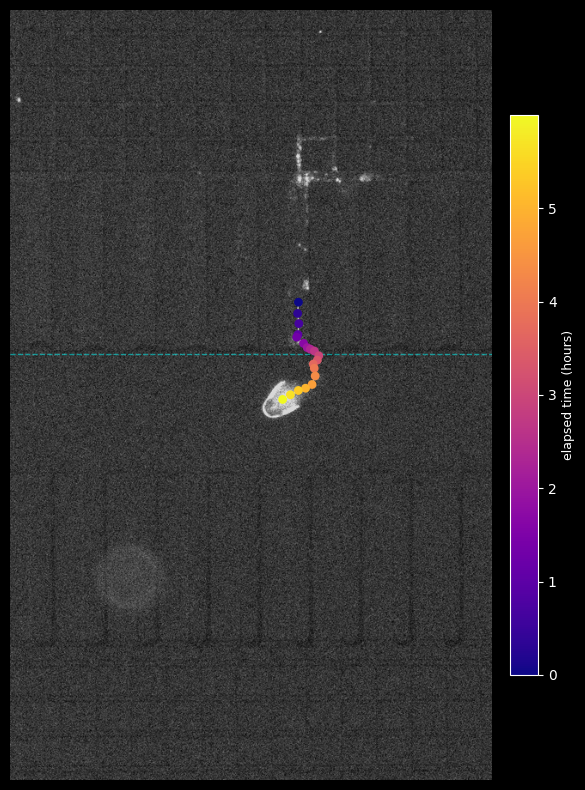

In [44]:

%matplotlib inline
# ── Centroid trajectory for a single track, colour-coded by time ─────────────
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
plt.style.use('dark_background')
SELECTED_TRACK_ID = 3   # ← change this to the track you want to inspect

# Use last frame as background
_, bg_disp = get_frame(czi, n_times - 1, channel, gamma=1, stretch_min=1, stretch_max=99.5)
bg_disp = select_roi(bg_disp)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(bg_disp, cmap="gray")

cmap = cm.plasma
grp = df_agg[df_agg["track_id"] == SELECTED_TRACK_ID].sort_values("time")
if grp.empty:
    print(f"Track ID {SELECTED_TRACK_ID} not found. Available IDs: {sorted(df_agg['track_id'].unique())}")
else:
    xs = grp["centroid_x_um"] / px_um
    ys = grp["centroid_y_um"] / px_um
    time_hours = grp["time_s"] / 3600  # convert seconds to hours

    # Trajectory line
    ax.plot(xs, ys, color="white", linewidth=1.0, alpha=0.6, zorder=2)

    # Scatter points coloured by time
    norm = mcolors.Normalize(vmin=time_hours.min(), vmax=time_hours.max())
    sc = ax.scatter(xs, ys, c=time_hours, cmap=cmap, norm=norm,
                    s=40, linewidths=0, zorder=3)

    cbar = fig.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
    cbar.set_label("elapsed time (hours)", fontsize=9)

ax.axhline(y=y_threshold_px, color='cyan', linestyle='--', linewidth=1, alpha=0.5)
# ax.set_title(f"Track {SELECTED_TRACK_ID} — centroid trajectory (colour = time)", fontsize=10)
ax.axis("off")
plt.tight_layout()


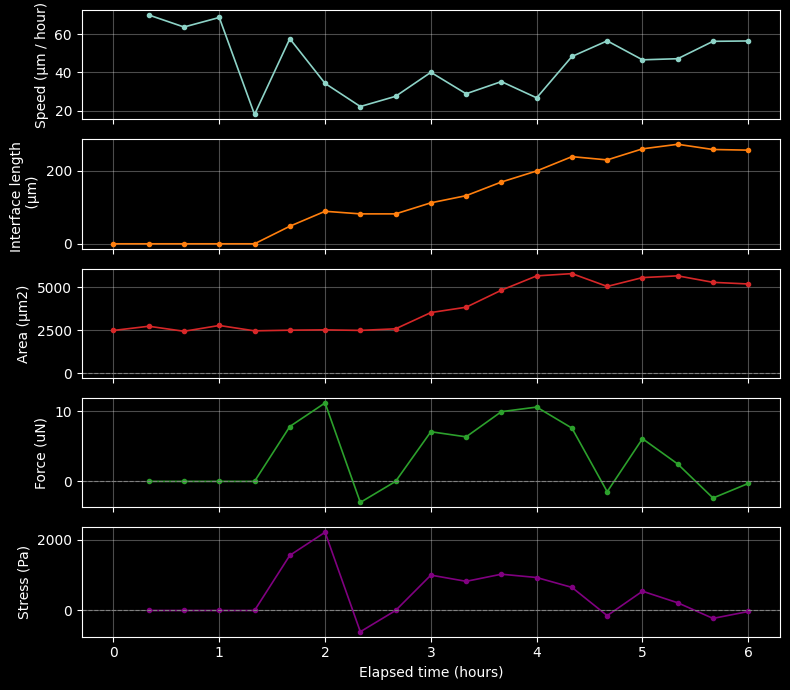

In [50]:
width = 40 #um
gamma = 0.078 #uN/um

# ── Time-series metrics for a single track ────────────────────────────────────
grp = df_agg[df_agg["track_id"] == SELECTED_TRACK_ID].sort_values("time").copy()

if grp.empty:
    print(f"Track ID {SELECTED_TRACK_ID} not found.")
else:
    # ── Speed (µm / hour) ────────────────────────────────────────────────────
    dx = grp["centroid_x_um"].diff()
    dy = grp["centroid_y_um"].diff()
    distance_um = np.sqrt(dx**2 + dy**2)
    dt_hours = grp["time_s"].diff() / 3600  # time difference in hours
    grp["speed_um_per_hour"] = distance_um / dt_hours

    # ── Derivative of boundary_above_um (µm / frame) ─────────────────────────
    grp["d_boundary_above"] = grp["boundary_above_um"].diff()/ dt_hours
    grp["dS/dt"] = width *grp["boundary_above_um"].diff()/ distance_um
    grp["F"] = gamma * grp["dS/dt"]
    grp["Stress"] = grp["F"]/(2*grp["area_um2"]) *1e6 #Pa




    t_hours = grp["time_s"].values / 3600  # convert seconds to hours

    fig, axes = plt.subplots(5, 1, figsize=(8, 7), sharex=True)

    # Speed
    axes[0].plot(t_hours, grp["speed_um_per_hour"], marker='o', markersize=3, linewidth=1.2)
    axes[0].set_ylabel("Speed (µm / hour)")
    axes[0].grid(True, alpha=0.3)

    # boundary_above_um
    axes[1].plot(t_hours, grp["boundary_above_um"], marker='o', markersize=3,
                 linewidth=1.2, color="tab:orange")
    axes[1].set_ylabel("Interface length \n (µm)")
    axes[1].grid(True, alpha=0.3)

    # derivative of boundary_above_um
    axes[2].plot(t_hours, grp["area_um2"], marker='o', markersize=3,
                 linewidth=1.2, color="tab:red")
    axes[2].axhline(0, color="gray", linewidth=0.8, linestyle="--")
    axes[2].set_ylabel("Area (µm2)")
    axes[2].grid(True, alpha=0.3)
    axes[3].plot(t_hours, grp["F"], marker='o', markersize=3,
                 linewidth=1.2, color="tab:green")
    axes[3].axhline(0, color="gray", linewidth=0.8, linestyle="--")
    axes[3].set_ylabel("Force (uN)")
    axes[3].grid(True, alpha=0.3)
    axes[4].plot(t_hours, grp["Stress"], marker='o', markersize=3,
                 linewidth=1.2, color="purple")
    axes[4].axhline(0, color="gray", linewidth=0.8, linestyle="--")
    axes[4].set_ylabel("Stress (Pa)")
    axes[4].set_xlabel("Elapsed time (hours)")
    axes[4].grid(True, alpha=0.3)
    plt.tight_layout()
